# Compute super-resolution spectrograms using UOT

The purpose of this notebook is to serve as a tutorial to compute super-resolution spectrograms using UOT barycenters. We'll cover the following steps:

* Load a signal using librosa.
* Compute two spectrograms with different window length.
* Define the input and target grids.
* Compute the cost matrices.
* Compute the UOT barycenter.
* Compare

In [1]:
import librosa
from src.spectrogram import *
from src.barycenter import *
from src.cost_matrix import *
from src.display import *
from src.spectrogram import *
from src.utils import *

## Load the signal

We work with audio signals, for which librosa is a practical tool.

For other types of signals, you only need to store the samples in a NumPy array.

/Users/davidv/david/code/papers/fusion-ot/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


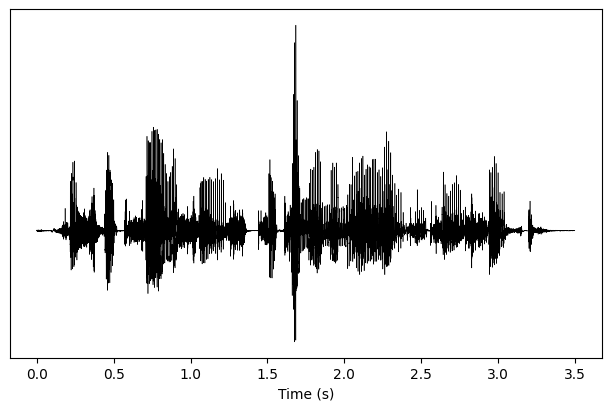

In [2]:
sr = 8000
signal, _ = librosa.load('example_sounds/man_speech.wav', sr=sr)
t = np.arange(signal.size) / sr

plot_signal(signal, times=t)

# Compute spectrograms

To compute spectrograms we use the Spectrogram class.

The required parameters are the signal, the sample rate and the window_size in seconds. If other parameters (eg. hop size or Nfft) are not provided, then we use standard defaults, eg 50% overlap, Nfft = window size (in samples)

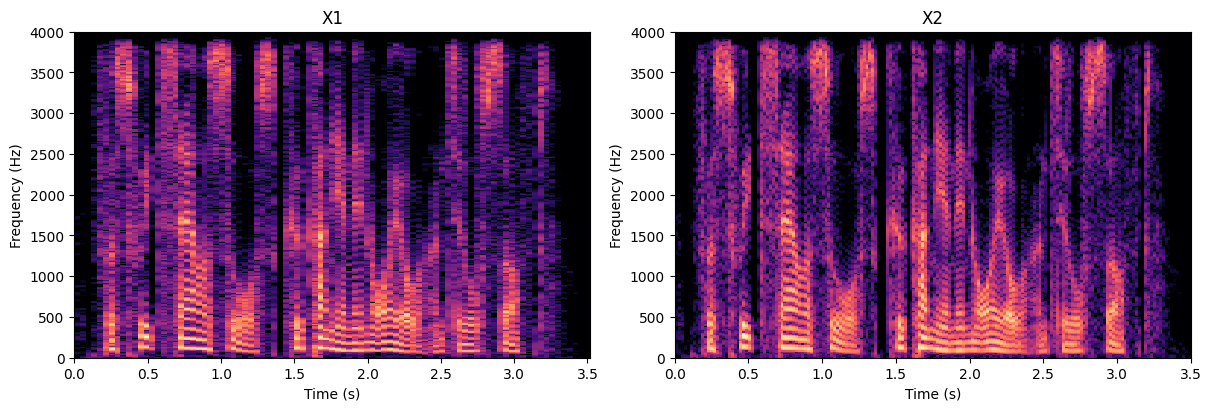

In [3]:
X1 = Spectrogram(signal, sr, window_size_s=80e-3, hop_size_s=40e-3, nfft=1024)
X2 = Spectrogram(signal, sr, window_size_s=40e-3, hop_size_s=20e-3, nfft=512)

x1 = X1.spectrogram() # these are standard np arrays containing the spectrograms
x2 = X2.spectrogram()

# Display the spectrograms
axes = new_axes(1, 2) # useful to handle multiple images in matplotlib
display_spectrogram(x1, ax=axes[0], title='X1', f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-60)
display_spectrogram(x2, ax=axes[1], title='X2', f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-60)

## Define cost matrices

We compute the cost matrices considering time and frequency overlap from equations 26 and 27.

These cost matrices have infinite entries, which we discard. As so, the resulting object is no longer a matrix. We represent it with a vector.

To provide the relationship between matrix entry $C_{ij}$ and vector entry $c_k$ we use the rows and columns indicies arrays.

As such, `i=rows[k]`, `j=cols[k]`, `C[i, j] = C[rows[k], cols[k]] = c[k]`.

In [4]:
c1, rows1, cols1 = cost_matrix_horizontal_overlap(X1.f_bins, X1.t_frames, X2.t_frames, X1.window_size, X2.window_size, X1.hop_size, X2.hop_size)
c2, rows2, cols2 = cost_matrix_vertical_overlap(X1.f_bins, X2.f_bins, X2.t_frames, X1.window_size, X2.window_size)

Removing the infinite entries drastically reduces the size of the problem. Let's see how much

In [5]:
# compute the original number of entries of the cost matrices i.e. before vectorization

C1_original_size = X1.f * X1.t * X1.f * X2.t # X.f is the number of frequency bins, X.t is the number of time frames
C2_original_size = X2.f * X2.t * X1.f * X2.t

print(f"Size of c1: {c1.size}, which corresponds to {100 * c1.size / C1_original_size:.3f}% of original matrix.")
print(f"Size of c2: {c2.size}, which corresponds to {100 * c2.size / C2_original_size:.3f}% of original matrix.")

Size of c1: 314469, which corresponds to 0.008% of original matrix.
Size of c2: 862400, which corresponds to 0.021% of original matrix.


## Compute UOT barycenters

In [6]:
# To compute barycenters we must first vectorize in a column-wise fashion the input spectrograms.
# For this we first take the transpose (column-wise) and then flatten (vectorization).

x1_vect = x1.T.flatten()
x2_vect = x2.T.flatten()

# Now the other parameters

eta       = 1 # UOT parameter
bary_size = X1.f_bins.size * X2.t_frames.size # number of entries of the barycenter
nItermax  = 500 # maximum number of iterations


x_UOT, loss_UOT, diff_UOT = uot_barycenter(x1.T.flatten(), 
                                           x2.T.flatten(), 
                                           c1, 
                                           c2, 
                                           rows1,
                                           cols1,
                                           rows2,
                                           cols2,
                                           eta=eta,
                                           bary_size=bary_size,
                                           nItermax=nItermax,
                                           return_loss=True, # return objective values
                                           return_diff=True, # return norm difference between the iterates
                                           thr=1e-5)

x_UOT = x_UOT.reshape(X2.t, X1.f).T # reshape vector to spectrogram shape

Convergence attained after 52 iterations.


Let's visualize results

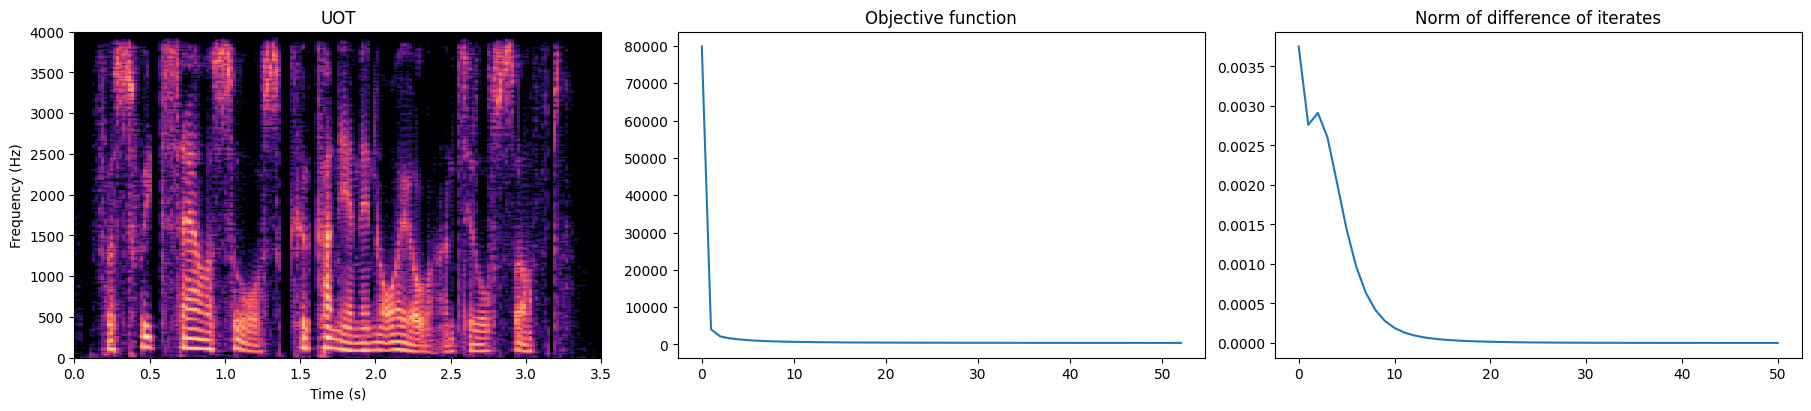

In [7]:
axes = new_axes(1, 3)
display_spectrogram(x_UOT, ax=axes[0], title='UOT', f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, logmin=-60)
axes[1].plot(loss_UOT)
axes[1].set_title("Objective function")
axes[2].plot(diff_UOT)
axes[2].set_title("Norm of difference of iterates");

## Comparison

Let's compare the results with the original spectrograms

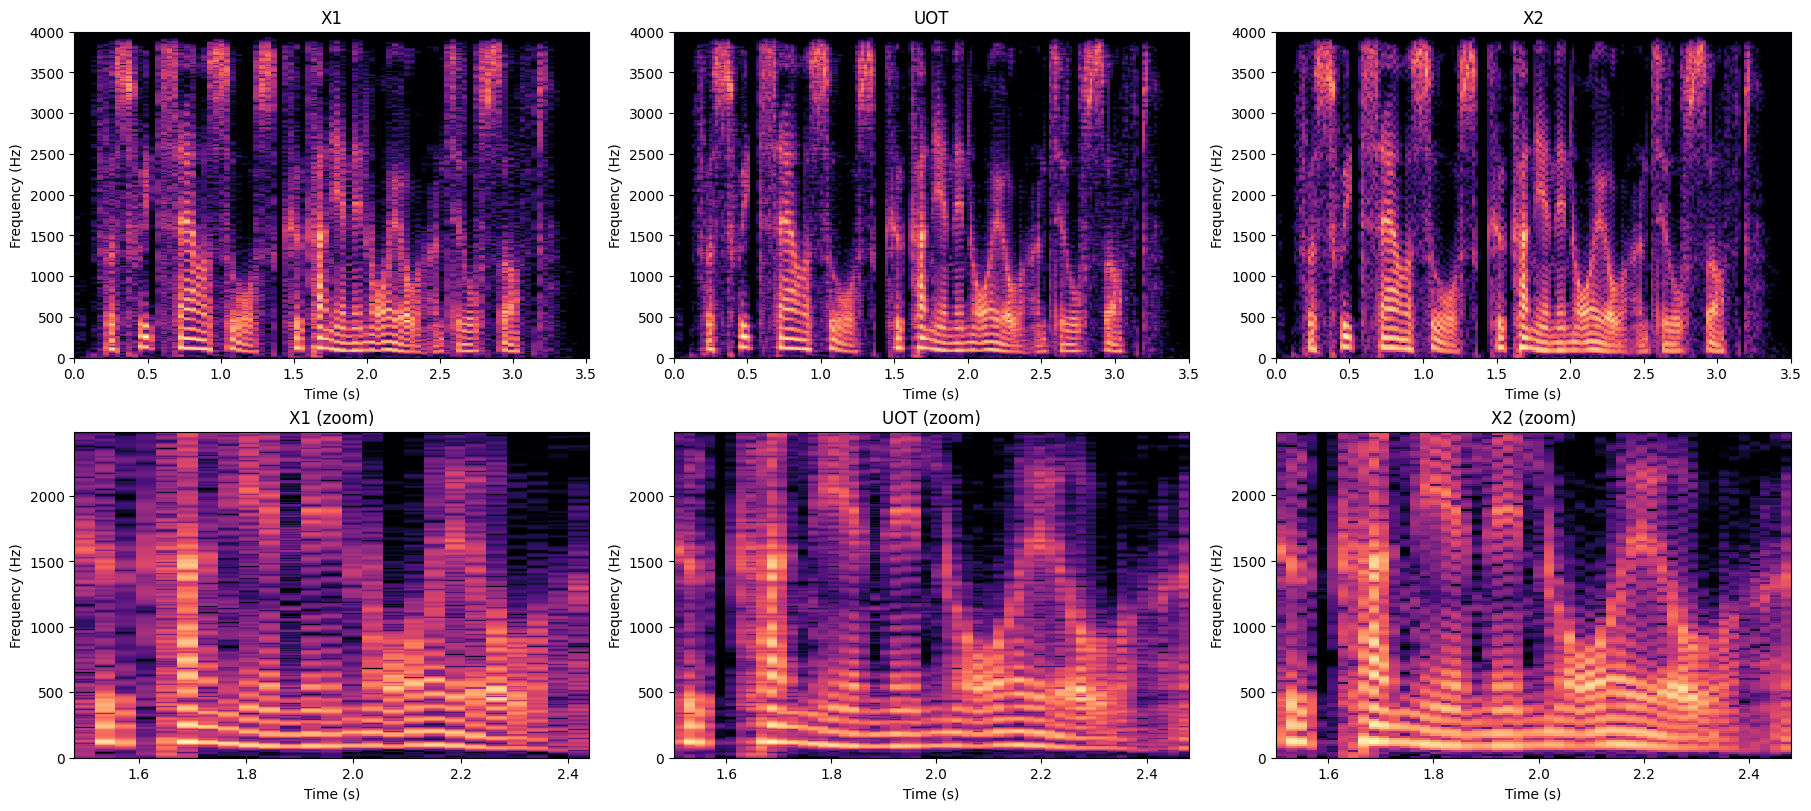

In [8]:
axes = new_axes(2, 3)
display_spectrogram(x1,    ax=axes[0, 0], title='X1',  f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-60)
display_spectrogram(x_UOT, ax=axes[0, 1], title='UOT', f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, logmin=-60)
display_spectrogram(x2,    ax=axes[0, 2], title='X2',  f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-60)

# Let's do some zooms

low_t, high_t = 1.5, 2.5 # filter between time frames 1.5s and 2.5s
high_f = 2500 # remove frequencies above 2500Hz

display_spectrogram(x1,    ax=axes[1, 0], title='X1 (zoom)',  f_bins=X1.f_bins, t_frames=X1.t_frames, log=True, logmin=-60, low_t=low_t, high_t=high_t, high_f=high_f)
display_spectrogram(x_UOT, ax=axes[1, 1], title='UOT (zoom)', f_bins=X1.f_bins, t_frames=X2.t_frames, log=True, logmin=-60, low_t=low_t, high_t=high_t, high_f=high_f)
display_spectrogram(x2,    ax=axes[1, 2], title='X2 (zoom)',  f_bins=X2.f_bins, t_frames=X2.t_frames, log=True, logmin=-60, low_t=low_t, high_t=high_t, high_f=high_f)